# CadQuery - 長方形立體範例（逐步預覽）

In [12]:
import cadquery as cq
from cadquery.occ_impl.exporters.svg import getSVG
from IPython.display import SVG, display
from OCP.gp import gp_Ax2, gp_Pnt, gp_Dir

def show(obj):
    """在 notebook 中預覽 CadQuery 物件 (Z 軸朝上，含 XYZ 軸指示)"""
    shape = obj.val() if hasattr(obj, 'val') else obj
    proj_dir = (-1.75, 1.1, 0.5)  # Z 軸朝上的等角視圖
    w, h = 400, 350
    opts = {
        "width": w,
        "height": h,
        "marginLeft": 10,
        "marginTop": 10,
        "projectionDir": proj_dir,
        "showAxes": False,
        "showHidden": True,
    }
    svg_str = getSVG(shape, opts)

    # 計算 XYZ 軸在螢幕上的投影方向
    ax = gp_Ax2(gp_Pnt(), gp_Dir(*proj_dir))
    sx = (ax.XDirection().X(), ax.XDirection().Y(), ax.XDirection().Z())
    sy = (ax.YDirection().X(), ax.YDirection().Y(), ax.YDirection().Z())
    axes_svg = f'<g transform="translate(15,{h - 15})" fill="none">\n'
    axis_len = 30
    origin = (20, -20)
    for name, color, world in [("X", "#E03030", (1,0,0)),
                                ("Y", "#30A030", (0,1,0)),
                                ("Z", "#3060E0", (0,0,1))]:
        px = sum(w * s for w, s in zip(world, sx)) * axis_len
        py = -sum(w * s for w, s in zip(world, sy)) * axis_len
        x2 = origin[0] + px
        y2 = origin[1] + py
        axes_svg += f'  <line x1="{origin[0]}" y1="{origin[1]}" x2="{x2:.1f}" y2="{y2:.1f}" stroke-width="2" stroke="{color}"/>\n'
        axes_svg += f'  <text x="{x2+3:.1f}" y="{y2+3:.1f}" font-size="12" stroke="none" fill="{color}">{name}</text>\n'
    axes_svg += '</g>'

    svg_str = svg_str.replace('</svg>', axes_svg + '\n</svg>')
    display(SVG(svg_str))

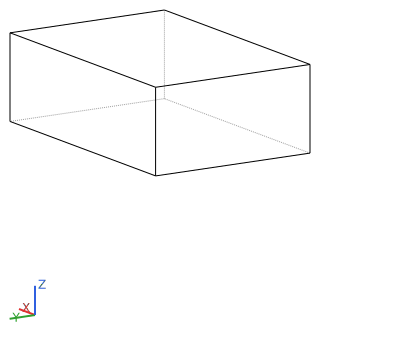

In [13]:
# Step 1: 建立基本長方形立體 (60 x 40 x 20 mm)
box = cq.Workplane("XY").box(60, 40, 20)
show(box)

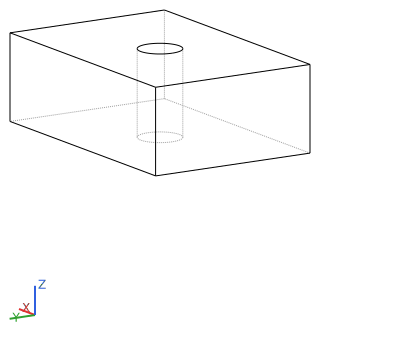

In [14]:
# Step 2: 在頂面挖一個圓孔 (直徑 10mm)
result = box.faces(">Z").workplane().hole(10)
show(result)

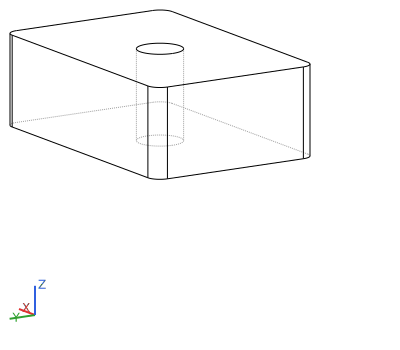

In [15]:
# Step 3: 對垂直邊做倒角 (圓角半徑 3mm)
result = result.edges("|Z").fillet(3)
show(result)

In [16]:
# Step 4: 匯出最終結果
cq.exporters.export(result, "box.stl")
cq.exporters.export(result, "box.step")
print("已匯出: box.stl, box.step")

已匯出: box.stl, box.step


# 匯入外部 3D 模型（噴霧瓶）

=== 原始噴霧瓶 (薄壁) ===


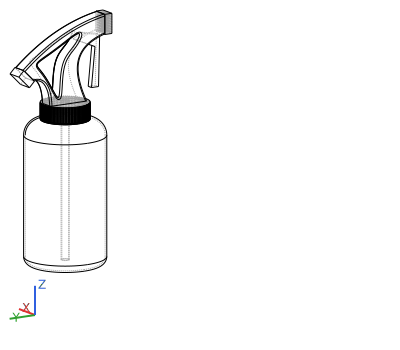


=== 實心包絡體 (spline): 10.0 x 13.2 x 30.0 mm ===


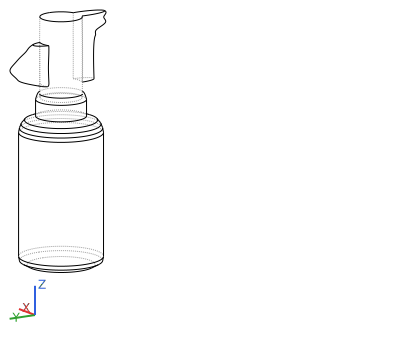

已匯出: spray_envelope.stl


In [17]:
from OCP.IGESControl import IGESControl_Reader

# 讀取原始 IGES
reader = IGESControl_Reader()
reader.ReadFile("online-models/spray-can-4/SPRAY v3.iges")
reader.TransferRoots()
spray_bottle = cq.Shape(reader.OneShape())

print("=== 原始噴霧瓶 (薄壁) ===")
show(spray_bottle)

# 建立精確實心包絡體 (拆成 4 部件, 各自 spline loft)
# -- 瓶身: 圓形截面 loft --
body_radii = [
    (0.0, 4.0), (0.5, 4.9), (1.0, 5.0), (16.0, 5.0),
    (16.5, 4.9), (17.0, 4.7), (17.5, 4.3), (18.0, 3.0), (20.0, 3.0),
]
parts = []
for i in range(len(body_radii) - 1):
    z0, r0 = body_radii[i]; z1, r1 = body_radii[i+1]; dz = z1 - z0
    if abs(r0 - r1) < 0.01:
        parts.append(cq.Workplane("XY").workplane(offset=z0).circle(r0).extrude(dz))
    else:
        parts.append(cq.Workplane("XY").workplane(offset=z0).circle(r0).workplane(offset=dz).circle(r1).loft())
body = parts[0]
for p in parts[1:]: body = body.union(p)

# -- 泵柱 (中央管, Z=20~30) --
pump_data = [(20.0, 3.0), (20.5, 2.5), (21.0, 2.5), (30.0, 2.5)]
wp = cq.Workplane("XY").workplane(offset=pump_data[0][0]).circle(pump_data[0][1])
pz = pump_data[0][0]
for z, r in pump_data[1:]:
    wp = wp.workplane(offset=z - pz).circle(r); pz = z
pump = wp.loft(ruled=False)

# -- 扳機/握把 (+Y 凸出, Z=22~27, spline loft) --
trigger_data = [
    (22.0, 0, 3.0), (23.0, 0, 5.9), (23.5, 0, 6.4), (24.0, 0, 6.9),
    (24.5, 0, 7.0), (25.0, 0, 6.5), (25.5, 0, 5.9), (26.0, 0, 5.2),
    (26.5, 0, 4.6), (27.0, 0, 3.8),
]
wp = cq.Workplane("XY").workplane(offset=trigger_data[0][0]).center(0, trigger_data[0][2]/2).ellipse(1, trigger_data[0][2]/2)
pz = trigger_data[0][0]; pcy = trigger_data[0][2]/2
for z, ys, ye in trigger_data[1:]:
    cy = (ys+ye)/2; ry = (ye-ys)/2
    wp = wp.workplane(offset=z-pz).center(0, cy-pcy).ellipse(1, ry); pz = z; pcy = cy
trigger = wp.loft(ruled=False)

# -- 噴嘴管 (-Y 方向, Z=22~30, spline loft) --
nozzle_data = [
    (22.0, -4.5, 0), (27.0, -4.6, 0), (27.5, -4.7, 0), (28.0, -5.0, 0),
    (28.5, -6.0, 0), (29.0, -6.0, 0), (29.5, -6.0, 0), (30.0, -6.0, 0),
]
wp = cq.Workplane("XY").workplane(offset=nozzle_data[0][0]).center(0, nozzle_data[0][1]/2).ellipse(1, abs(nozzle_data[0][1])/2)
pz = nozzle_data[0][0]; pcy = nozzle_data[0][1]/2
for z, ymin, ymax in nozzle_data[1:]:
    cy = (ymin+ymax)/2; ry = (ymax-ymin)/2
    wp = wp.workplane(offset=z-pz).center(0, cy-pcy).ellipse(1, ry); pz = z; pcy = cy
nozzle_pipe = wp.loft(ruled=False)

# 合併
spray_envelope = body.union(pump).union(trigger).union(nozzle_pipe)

bb = spray_envelope.val().BoundingBox()
print(f"\n=== 實心包絡體 (spline): {bb.xlen:.1f} x {bb.ylen:.1f} x {bb.zlen:.1f} mm ===")
show(spray_envelope)

cq.exporters.export(spray_envelope, "online-models/spray_envelope.stl")
print("已匯出: spray_envelope.stl")

噴霧瓶斜面支架

座標定義 (YZ截面):
- 楔形頂點: (0,0), (D,0), (0,H)，H/D = tan(30°)
- 斜面法線 n = (0, 0.5, 0.866)，與Z軸夾30°
- 斜面切線 t = (0, -0.866, 0.5)，與Z軸夾60° = 瓶軸方向

瓶子定位: 繞X軸+60° → 瓶軸//切線，平移至斜面中點 → 半沈浸
切割工具: spray_envelope (實心包絡體，根據IGES截面數據重建)

旋轉後 — Y: -29.0~2.0, Z: -4.0~18.3


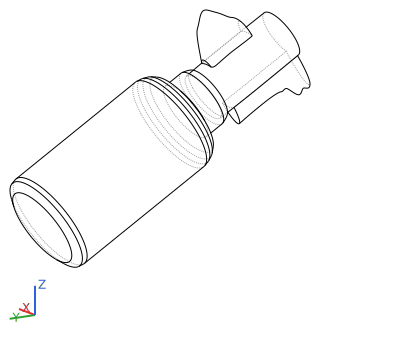

In [18]:
import math
from OCP.gp import gp_Trsf, gp_Ax1, gp_Pnt, gp_Dir, gp_Vec
from OCP.BRepBuilderAPI import BRepBuilderAPI_Transform
from OCP.BRepAlgoAPI import BRepAlgoAPI_Cut

# === Step 1: 旋轉包絡體 +60° 繞 X 軸 ===
trsf_rot = gp_Trsf()
trsf_rot.SetRotation(gp_Ax1(gp_Pnt(0, 0, 0), gp_Dir(1, 0, 0)), math.radians(60))
env_rot = cq.Shape(BRepBuilderAPI_Transform(spray_envelope.val().wrapped, trsf_rot, True).Shape())

rbb = env_rot.BoundingBox()
print(f"旋轉後 — Y: {rbb.ymin:.1f}~{rbb.ymax:.1f}, Z: {rbb.zmin:.1f}~{rbb.zmax:.1f}")
show(env_rot)

In [19]:
# === Step 2: 楔形尺寸 + 定位 (加高避免穿孔) ===
margin = 4
bb_env = spray_envelope.val().BoundingBox()
slope_len = bb_env.zlen + 2 * margin

H_base = slope_len * math.sin(math.radians(30))
D_base = slope_len * math.cos(math.radians(30))
W_half = bb_env.xlen / 2 + margin

# 先用基本尺寸定位
trsf_move = gp_Trsf()
trsf_move.SetTranslation(gp_Vec(0, D_base/2 - rbb.center.y, H_base/2 - rbb.center.z))
env_test = cq.Shape(BRepBuilderAPI_Transform(env_rot.wrapped, trsf_move, True).Shape())

# 加高楔形: H 至少要蓋住瓶子最高點 + margin
H = max(H_base, env_test.BoundingBox().zmax + margin)
D = H / math.tan(math.radians(30))

# 用最終 H/D 重新定位
trsf_move = gp_Trsf()
trsf_move.SetTranslation(gp_Vec(0, D/2 - rbb.center.y, H/2 - rbb.center.z))
env_positioned = cq.Shape(BRepBuilderAPI_Transform(env_rot.wrapped, trsf_move, True).Shape())

pbb = env_positioned.BoundingBox()
print(f"楔形: H={H:.1f}, D={D:.1f} (加高後)")
print(f"瓶子頂: Z={pbb.zmax:.1f} < 楔形高: {H:.1f} ✓ 不穿孔")

楔形: H=24.9, D=43.1 (加高後)
瓶子頂: Z=23.6 < 楔形高: 24.9 ✓ 不穿孔


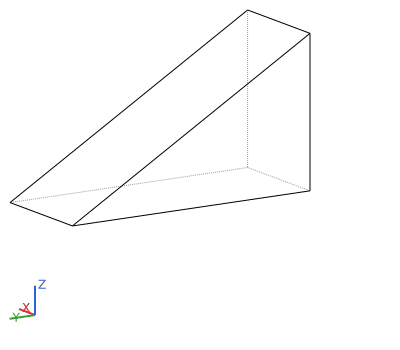

In [20]:
# === Step 3: 建立楔形 ===
wedge = (
    cq.Workplane("YZ")
    .moveTo(0, 0).lineTo(D, 0).lineTo(0, H).close()
    .extrude(W_half, both=True)
)
show(wedge.val())

切割完成


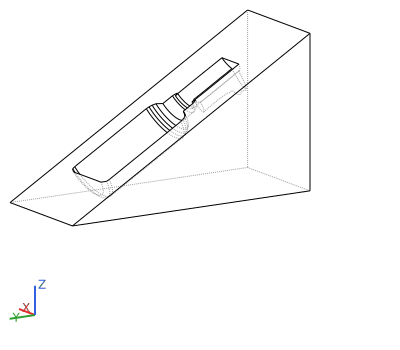

In [21]:
# === Step 4: 布林切割 ===
holder = cq.Shape(BRepAlgoAPI_Cut(wedge.val().wrapped, env_positioned.wrapped).Shape())
print("切割完成")
show(holder)

In [22]:
# === Step 5: 匯出 ===
cq.exporters.export(cq.Workplane().add(holder), "spray_bottle_holder.step")
cq.exporters.export(cq.Workplane().add(holder), "spray_bottle_holder.stl")
print("已匯出: spray_bottle_holder.step, spray_bottle_holder.stl")

已匯出: spray_bottle_holder.step, spray_bottle_holder.stl


# Coffee cup

In [1]:
import cadquery as cq
from cadquery.occ_impl.exporters.svg import getSVG
from IPython.display import SVG, display
from OCP.gp import gp_Ax2, gp_Pnt, gp_Dir

def show(obj):
    """在 notebook 中預覽 CadQuery 物件 (Z 軸朝上，含 XYZ 軸指示)"""
    shape = obj.val() if hasattr(obj, 'val') else obj
    proj_dir = (-1.75, 1.1, 0.5)
    w, h = 400, 350
    opts = {
        "width": w, "height": h,
        "marginLeft": 10, "marginTop": 10,
        "projectionDir": proj_dir,
        "showAxes": False, "showHidden": True,
    }
    svg_str = getSVG(shape, opts)
    ax = gp_Ax2(gp_Pnt(), gp_Dir(*proj_dir))
    sx = (ax.XDirection().X(), ax.XDirection().Y(), ax.XDirection().Z())
    sy = (ax.YDirection().X(), ax.YDirection().Y(), ax.YDirection().Z())
    axes_svg = f'<g transform="translate(15,{h - 15})" fill="none">\n'
    axis_len, origin = 30, (20, -20)
    for name, color, world in [("X","#E03030",(1,0,0)),("Y","#30A030",(0,1,0)),("Z","#3060E0",(0,0,1))]:
        px = sum(w*s for w,s in zip(world, sx)) * axis_len
        py = -sum(w*s for w,s in zip(world, sy)) * axis_len
        x2, y2 = origin[0]+px, origin[1]+py
        axes_svg += f'  <line x1="{origin[0]}" y1="{origin[1]}" x2="{x2:.1f}" y2="{y2:.1f}" stroke-width="2" stroke="{color}"/>\n'
        axes_svg += f'  <text x="{x2+3:.1f}" y="{y2+3:.1f}" font-size="12" stroke="none" fill="{color}">{name}</text>\n'
    axes_svg += '</g>'
    svg_str = svg_str.replace('</svg>', axes_svg + '\n</svg>')
    display(SVG(svg_str))

=== 咖啡杯 STL: 101.2 x 93.3 x 82.7 mm ===
    中心: (150.0, 150.0, 41.3)


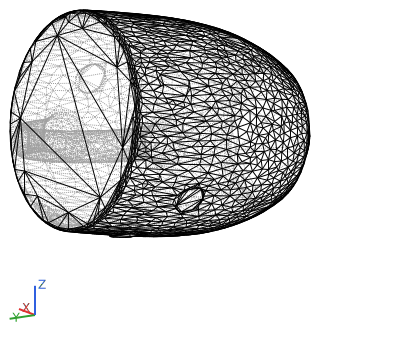


=== 包絡體: ⌀128.0 x H82.7 mm ===


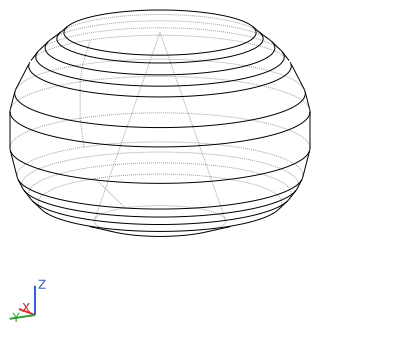

In [2]:
from OCP.StlAPI import StlAPI_Reader
from OCP.TopoDS import TopoDS_Shape

# === 讀取咖啡杯 STL (Revo Scan 掃描) ===
stl_shape = TopoDS_Shape()
stl_reader = StlAPI_Reader()
stl_reader.Read(stl_shape, "revo-scan/0430_01_mesh_auto1.stl")
cup_mesh = cq.Shape(stl_shape)

bb = cup_mesh.BoundingBox()
print(f"=== 咖啡杯 STL: {bb.xlen:.1f} x {bb.ylen:.1f} x {bb.zlen:.1f} mm ===")
print(f"    中心: ({bb.center.x:.1f}, {bb.center.y:.1f}, {bb.center.z:.1f})")
show(cup_mesh)

# === 建立簡化實心包絡體 (旋轉體) ===
# 各高度最大半徑 (含把手), 從 STL 截面分析取得
# (Z 高度 mm, 最大半徑 mm)
cup_radii = [
    ( 0.0, 27), ( 4.0, 39), ( 8.0, 51), (12.0, 55),
    (16.0, 58), (20.0, 60), (24.0, 61), (28.0, 62),
    (32.0, 63), (36.0, 63), (40.0, 63), (44.0, 63),
    (48.0, 63), (52.0, 62), (56.0, 61), (60.0, 59),
    (64.0, 57), (68.0, 55), (72.0, 52), (76.0, 48),
    (80.0, 43), (82.7, 40),
]

clearance = 1.0  # mm 餘裕
outer_pts = [(r + clearance, z) for z, r in cup_radii]
top_z = cup_radii[-1][0]

cup_envelope = (
    cq.Workplane("XZ")
    .polyline(outer_pts)       # 從 (0,0) → 外輪廓
    .lineTo(0, top_z)          # → 頂部中心
    .close()                   # → 回到 (0,0)
    .revolve(360)              # 繞 Z 軸旋轉
)

ebb = cup_envelope.val().BoundingBox()
print(f"\n=== 包絡體: ⌀{ebb.xlen:.1f} x H{ebb.zlen:.1f} mm ===")
show(cup_envelope)

In [ ]:
# === 收納架設計: 方形底座 + 杯形凹槽 ===
wall = 5        # 壁厚 mm
floor = 5       # 底板厚 mm
sink = 40       # 杯子沈入深度 mm

ebb = cup_envelope.val().BoundingBox()
max_r = ebb.xlen / 2

# 底座: 方形 + 垂直邊倒圓角
side = 2 * (max_r + wall)
base_h = sink + floor

base = (
    cq.Workplane("XY")
    .rect(side, side)
    .extrude(base_h)
    .edges("|Z").fillet(10)
)

# 包絡體平移: 杯底對齊底板頂面 (Z = floor)
cup_cut = cup_envelope.translate((0, 0, floor))

# 布林切割
holder = base.cut(cup_cut)

hbb = holder.val().BoundingBox()
print(f"收納架: {hbb.xlen:.0f} x {hbb.ylen:.0f} x {hbb.zlen:.0f} mm")
print("切割完成")
show(holder)

In [ ]:
# === 匯出 ===
cq.exporters.export(holder, "cup_holder.step")
cq.exporters.export(holder, "cup_holder.stl")
print("已匯出: cup_holder.step, cup_holder.stl")